# IID Mutations for Joe

In [1]:
!date

Sun Aug 26 21:52:35 CDT 2018


In [2]:
%matplotlib notebook
%run ../Code/bs.py
plt.rcParams['animation.embed_limit'] = 40 # megabytes

## Compare single mutation effect to additive i.i.d. mutation effects

In [3]:
%run -i ../Code/multiprecision_gamma.py
%run -i ../Code/gamma.py

**Define distributions for 501 types and 50001 types.**

In [4]:
def define_distributions(n_types):
    factors = Factors(n_types)
    one_mutation = WeightedDoubleGamma(factors)
    iid_mutations = WeightedDoubleGamma(factors)
    iid_mutations.iid_effects(number_of_mutations=1, log_number_of_loci=14)
    return one_mutation, iid_mutations

d500 = define_distributions(501)    # As in Section 5.4
d50k = define_distributions(50001)  # Increase number of types by factor of 100

**Plot distributions for 501 types**

The second plot is the same as the first, except for the limits on the vertical scale.

<IPython.core.display.Javascript object>


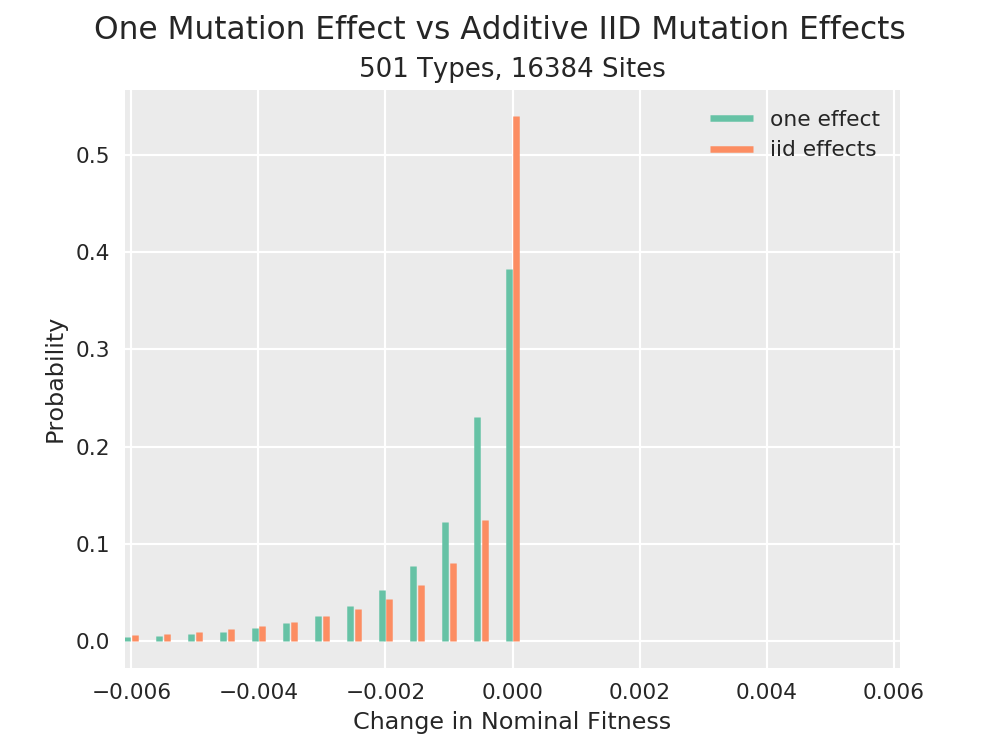

<IPython.core.display.Javascript object>


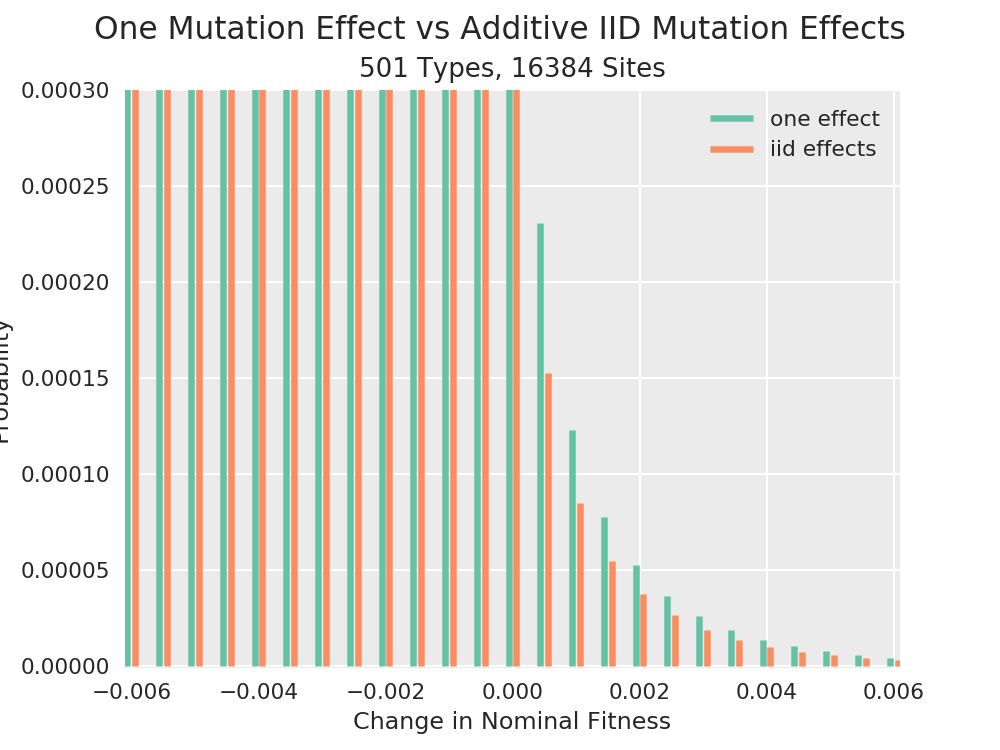

Probability of zero effect with one mutation : 0.38292492254802624
Probability of zero effect with iid mutations: 0.5395620585447671


In [5]:
def plot_gamma(distributions, xlim, ylim=None):
    one_mutation, iid_mutations = distributions
    fig, ax = plt.subplots()
    v = one_mutation.vlines(ax, x_offset=-xlim/100, label="one effect")
    v.set_color(sns.color_palette()[0])
    v = iid_mutations.vlines(ax, x_offset=xlim/100, label="iid effects")
    v.set_color(sns.color_palette()[1])
    ax.set_xlim(-xlim, xlim)
    ax.set_ylim(ylim)
    fig.suptitle('One Mutation Effect vs Additive IID Mutation Effects')
    ax.set_title('{0} Types, {1} Sites'.format(len(one_mutation) // 2 + 1, 2**iid_mutations.log_number_of_loci))
    ax.legend(loc='best')
    return fig, ax

fig, ax = plot_gamma(d500, xlim=0.0061)
fig, ax = plot_gamma(d500, xlim=0.0061, ylim=(-0.000001, 0.0003))
print('Probability of zero effect with one mutation :', max(d500[0]))
print('Probability of zero effect with iid mutations:', max(d500[1]))

**Plot distributions for 50001 types**

The second plot is the same as the first, except for the limits on the vertical scale.

<IPython.core.display.Javascript object>


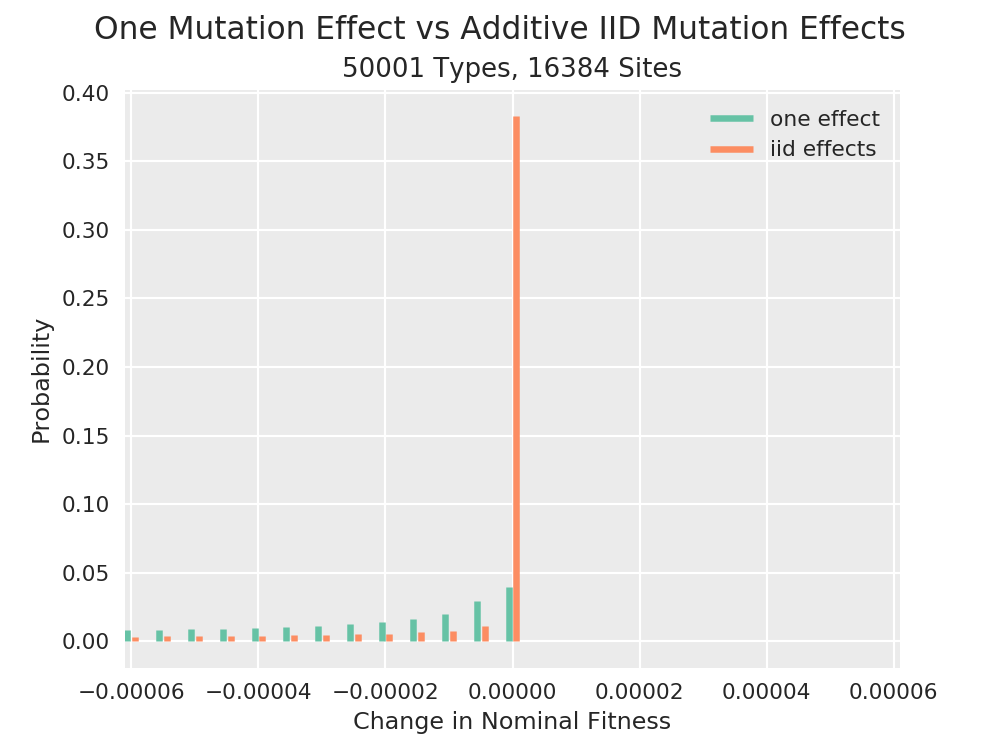

<IPython.core.display.Javascript object>


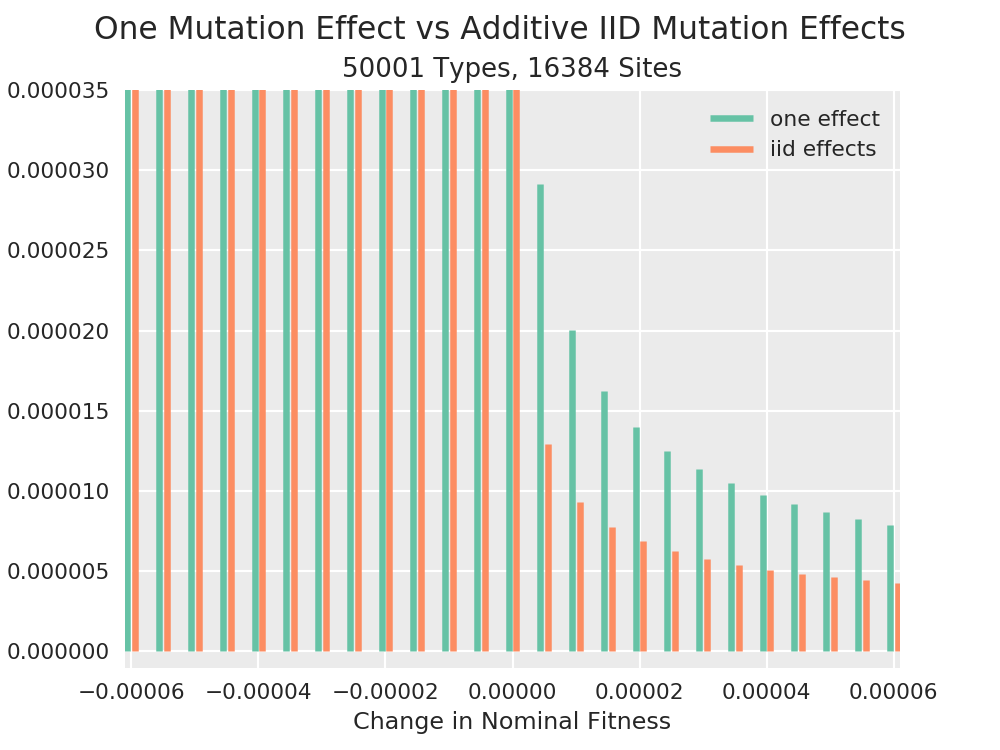

Probability of zero effect with one mutation : 0.039877611676744924
Probability of zero effect with iid mutations: 0.3828371932397536


In [6]:
fig, ax = plot_gamma(d50k, xlim=0.000061)
fig, ax = plot_gamma(d50k, xlim=0.000061, ylim=(-0.000001, 0.000035))
print('Probability of zero effect with one mutation :', max(d50k[0]))
print('Probability of zero effect with iid mutations:', max(d50k[1]))